# LSTM Time Series Forecasting

This notebook builds an LSTM model to forecast atmospheric CO2 levels.
The dataset is the **Mauna Loa weekly CO2** series, loaded directly from `statsmodels`' built-in datasets (`sm.datasets.co2`) - no download or external file needed.

## Task 1: Data Preparation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

np.random.seed(7)

In [2]:
raw = sm.datasets.co2.load_pandas().data
df = raw.resample("W").mean()
df = df.reset_index().rename(columns={"index": "date"})
df.head()

,date,co2
0,1958-03-30,316.1
1,1958-04-06,317.3
2,1958-04-13,317.6
3,1958-04-20,317.5
4,1958-04-27,316.4


The raw weekly readings have some gaps, so we fill them using linear interpolation before doing anything else.

In [3]:
print("missing values:", df["co2"].isna().sum())
df["co2"] = df["co2"].interpolate()
print("missing after fill:", df["co2"].isna().sum())

missing values: 59
missing after fill: 0


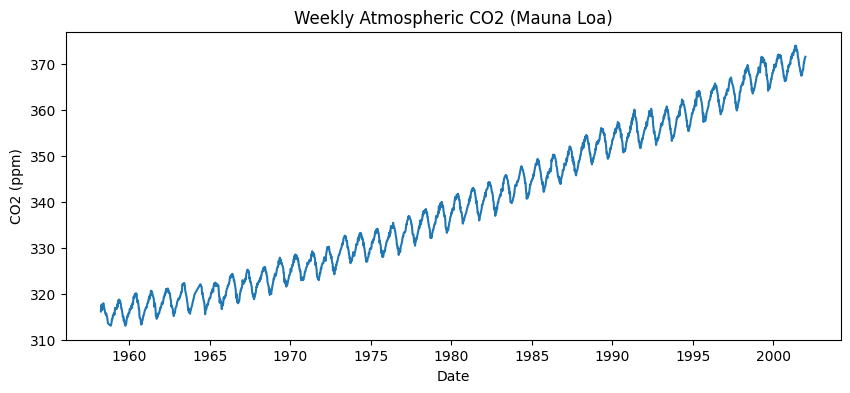

In [4]:
plt.figure(figsize=(10,4))
plt.plot(df["date"], df["co2"])
plt.title("Weekly Atmospheric CO2 (Mauna Loa)")
plt.xlabel("Date")
plt.ylabel("CO2 (ppm)")
plt.show()

Now the values are scaled to a 0-1 range with MinMaxScaler, since LSTMs train better on normalized data.

In [5]:
scaler = MinMaxScaler()
vals = df["co2"].values.reshape(-1, 1)
scaled = scaler.fit_transform(vals)

Next we turn the series into supervised sequences: each input is a window of past `seq_len` days, and the target is the next day's value.

In [6]:
def make_seqs(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len, 0])
        y.append(data[i+seq_len, 0])
    return np.array(X), np.array(y)

seq_len = 30
X, y = make_seqs(scaled, seq_len)
X = X.reshape(X.shape[0], X.shape[1], 1)
print(X.shape, y.shape)

(2254, 30, 1) (2254,)


In [7]:
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
print(X_train.shape, X_test.shape)

(1803, 30, 1) (451, 30, 1)


## Task 2: Design the LSTM Model

Four stacked LSTM layers are used, each with 50 units and a Dropout layer after it, followed by a single Dense output neuron for the forecast value.

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

model = Sequential([
    Input(shape=(seq_len, 1)),
    LSTM(50, return_sequences=True),
    Dropout(0.2),
    LSTM(50, return_sequences=True),
    Dropout(0.2),
    LSTM(50, return_sequences=True),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 30, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,051 (277.54 KB)

 Trainable params: 71,051 (277.54 KB)

 Non-trainable params: 0 (0.00 B)

## Task 3: Model Training

In [9]:
model.compile(optimizer="adam", loss="mse")
history = model.fit(X_train, y_train, epochs=20, batch_size=32,
                     validation_split=0.1, verbose=1)

Epoch 1/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 11s 71ms/step - loss: 0.0097 - val_loss: 0.0093
Epoch 2/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - loss: 0.0035 - val_loss: 0.0020
Epoch 3/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 0.0035 - val_loss: 0.0018
Epoch 4/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - loss: 0.0029 - val_loss: 0.0048
Epoch 5/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - loss: 0.0029 - val_loss: 0.0022
Epoch 6/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - loss: 0.0024 - val_loss: 0.0017
Epoch 7/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - loss: 0.0024 - val_loss: 0.0012
Epoch 8/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - loss: 0.0022 - val_loss: 0.0051
Epoch 9/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 0.0023 - val_loss: 8.9914e-04
Epoch 10/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - loss: 0.0018 - val_loss: 7.4134e-04
Epoch 11/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0016 - val_loss: 5.7129e-04
Epoch 12/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/ste

In [10]:
train_loss = history.history["loss"]
print("final training loss:", train_loss[-1])

final training loss: 0.0009128281380981207


## Task 4: Performance Evaluation

In [11]:
pred_scaled = model.predict(X_test)
pred = scaler.inverse_transform(pred_scaled)
actual = scaler.inverse_transform(y_test.reshape(-1, 1))

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step


In [12]:
rmse = np.sqrt(mean_squared_error(actual, pred))
mae = mean_absolute_error(actual, pred)
mse = mean_squared_error(actual, pred)
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")

RMSE: 1.2050
MAE:  0.9256
MSE:  1.4520


## Task 5: Visualization

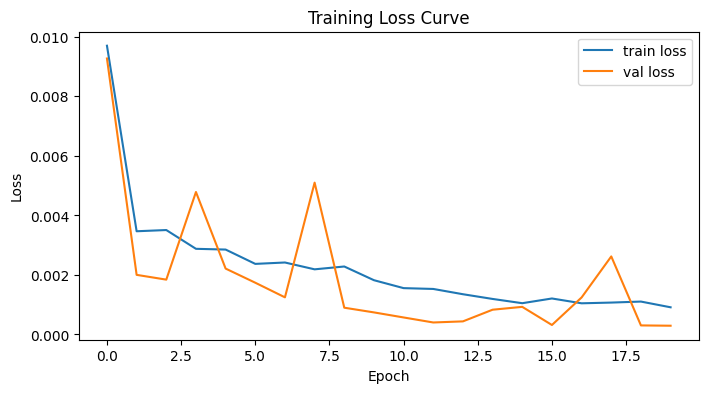

In [13]:
plt.figure(figsize=(8,4))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.legend()
plt.show()

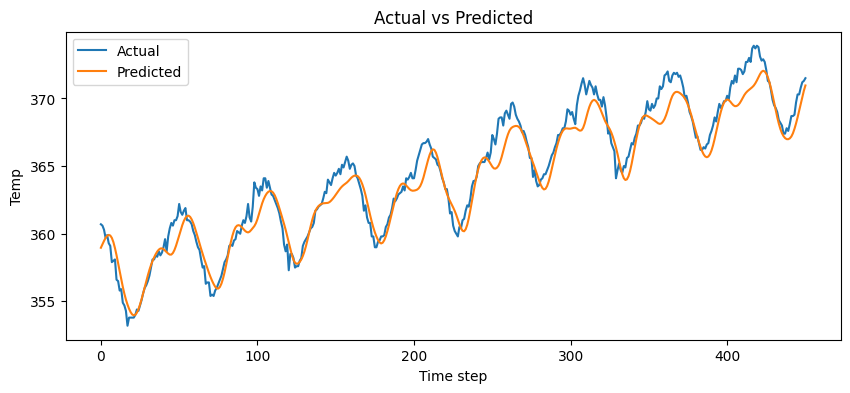

In [14]:
plt.figure(figsize=(10,4))
plt.plot(actual, label="Actual")
plt.plot(pred, label="Predicted")
plt.xlabel("Time step")
plt.ylabel("Temp")
plt.title("Actual vs Predicted")
plt.legend()
plt.show()

## Task 6: Hyperparameter Analysis

Three experiments are run below: changing the number of LSTM units, changing the dropout rate, and changing the sequence length. Each uses fewer epochs to keep training quick, and the results are compared using RMSE.

In [15]:
def build_and_run(seq_len_e, units, drop, epochs=8, batch=32):
    X_e, y_e = make_seqs(scaled, seq_len_e)
    X_e = X_e.reshape(X_e.shape[0], X_e.shape[1], 1)
    sp = int(len(X_e) * 0.8)
    Xtr, Xte = X_e[:sp], X_e[sp:]
    ytr, yte = y_e[:sp], y_e[sp:]

    m = Sequential([
        Input(shape=(seq_len_e, 1)),
        LSTM(units, return_sequences=True), Dropout(drop),
        LSTM(units, return_sequences=True), Dropout(drop),
        LSTM(units, return_sequences=True), Dropout(drop),
        LSTM(units, return_sequences=False), Dropout(drop),
        Dense(1)
    ])
    m.compile(optimizer="adam", loss="mse")
    m.fit(Xtr, ytr, epochs=epochs, batch_size=batch, verbose=0)

    p = scaler.inverse_transform(m.predict(Xte, verbose=0))
    a = scaler.inverse_transform(yte.reshape(-1,1))
    return np.sqrt(mean_squared_error(a, p))

In [16]:
results = {}
results["baseline (units=50, drop=0.2, seq=30)"] = build_and_run(30, 50, 0.2)
results["more units (units=100)"] = build_and_run(30, 100, 0.2)
results["higher dropout (drop=0.4)"] = build_and_run(30, 50, 0.4)
results["longer sequence (seq=60)"] = build_and_run(60, 50, 0.2)

for k, v in results.items():
    print(f"{k}: RMSE = {v:.4f}")

baseline (units=50, drop=0.2, seq=30): RMSE = 2.2074
more units (units=100): RMSE = 1.6553
higher dropout (drop=0.4): RMSE = 9.2764
longer sequence (seq=60): RMSE = 4.9204


In [17]:
best = min(results, key=results.get)
print("best performing setup:", best)

best performing setup: more units (units=100)


## Task 7: Model Analysis

**Why multiple LSTM layers?** Stacking LSTM layers lets the model learn patterns at different levels of abstraction. The first layer picks up short, local patterns in the sequence, while deeper layers can combine those into longer-term trends. A single LSTM layer often can't capture both at once.

**Purpose of Dropout.** Dropout randomly turns off a fraction of neurons during training, which stops the network from relying too heavily on any single unit. This reduces overfitting and helps the model generalize better to unseen data.

**Role of `return_sequences=True`.** When one LSTM layer feeds into another, the earlier layer needs to output a value for every time step (not just the last one), since the next LSTM layer expects a full sequence as input. Only the final LSTM layer before the Dense layer uses `return_sequences=False`, since we only need the last hidden state to predict the next value.

**Effect of hyperparameters.** Increasing the number of units gives the model more capacity, which can improve accuracy but also increases the risk of overfitting and training time. Raising dropout reduces overfitting but can hurt performance if set too high, since the model loses useful information during training. A longer sequence length gives the model more history to learn from, which sometimes helps but also makes training slower and can dilute recent, more relevant information.

**Strengths and limitations.** The model captures the upward trend and seasonal cycle in the CO2 series reasonably well and the loss curve shows stable convergence. Its main limitations are that it was trained on a fairly small dataset (a few thousand weekly points), it doesn't account for external variables that drive CO2 changes, and stacking four LSTM layers makes it slower to train than a shallower model without a clear accuracy gain in this case.